In [100]:
import importlib
import scipy.io
import utils.utils as u 
import utils.preprocessing as p 
import utils.models as m 
import numpy as np
import mne
import polars as pl
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
# Reload modules to reflect recent changes:
importlib.reload(u)
importlib.reload(p)
importlib.reload(m)
# Notice we are inside of src directory
!ls -la

"ls" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [101]:
files=u.get_file_names("../data", experiment="CLA")
print(files)

['../data/CLA-SubjectA-160108-3St-LRHand.mat', '../data/CLA-SubjectB-151019-3St-LRHand.mat', '../data/CLA-SubjectB-151020-3St-LRHand.mat', '../data/CLA-SubjectB-151215-3St-LRHand.mat', '../data/CLA-SubjectC-151126-3St-LRHand.mat', '../data/CLA-SubjectC-151216-3St-LRHand.mat', '../data/CLA-SubjectC-151223-3St-LRHand.mat', '../data/CLA-SubjectD-151125-3St-LRHand.mat', '../data/CLA-SubjectE-151225-3St-LRHand.mat', '../data/CLA-SubjectE-160119-3St-LRHand.mat', '../data/CLA-SubjectE-160122-3St-LRHand.mat', '../data/CLA-SubjectF-150916-3St-LRHand.mat', '../data/CLA-SubjectF-150917-3St-LRHand.mat', '../data/CLA-SubjectF-150928-3St-LRHand.mat', '../data/CLA-SubjectJ-170504-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170508-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170510-3St-LRHand-Inter.mat']


In [ ]:
#BASELINE

#metadata, data = u.read_file(files[0])
#raw=u.read_file_to_raw(files[0])
#events = u.find_events_from_marker(data["marker"], metadata["sampling_freq"][0])
#epochs = mne.Epochs(raw=raw, events=events, tmin= -0.1, tmax= +0.5, baseline=(None, 0), preload=True)
#df = u.epochs_to_polars(epochs)
#u.quick_XGBOOST_test(df)



Channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'A1', 'A2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
Creating RawArray with float64 data, n_channels=21, n_times=671600
    Range : 0 ... 671599 =      0.000 ...  3357.995 secs
Ready.
Successfully created Raw object
Not setting metadata
1920 matching events found
Setting baseline interval to [-0.1, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1920 events and 121 original time points ...
0 bad epochs dropped
(1920, 2541) (1920,)
Starting XGBoost training...
Training complete.

Model Accuracy on Test Set: 72.92%


(671600, 23)
Channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'A1', 'A2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
Creating RawArray with float64 data, n_channels=21, n_times=671600
    Range : 0 ... 671599 =      0.000 ...  3357.995 secs
Ready.
Successfully created Raw object
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-12 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-12 dB cutoff frequency: 45.00 Hz)
- Filter length: 661 samples (3.305 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) re

C:\Users\josub\AppData\Roaming\Python\Python312\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


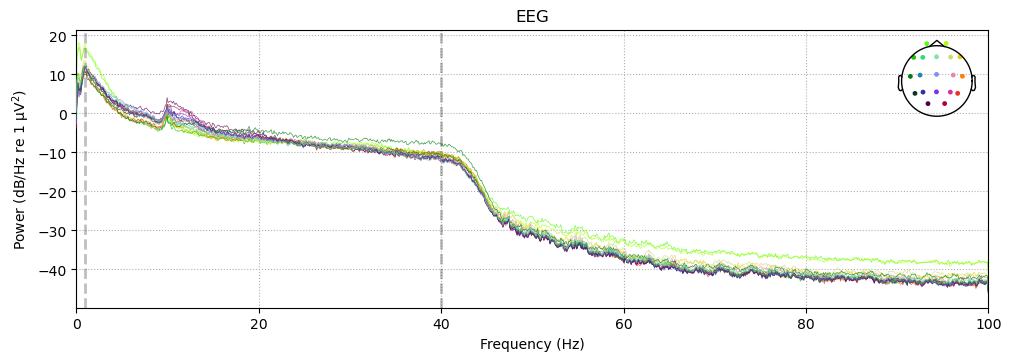

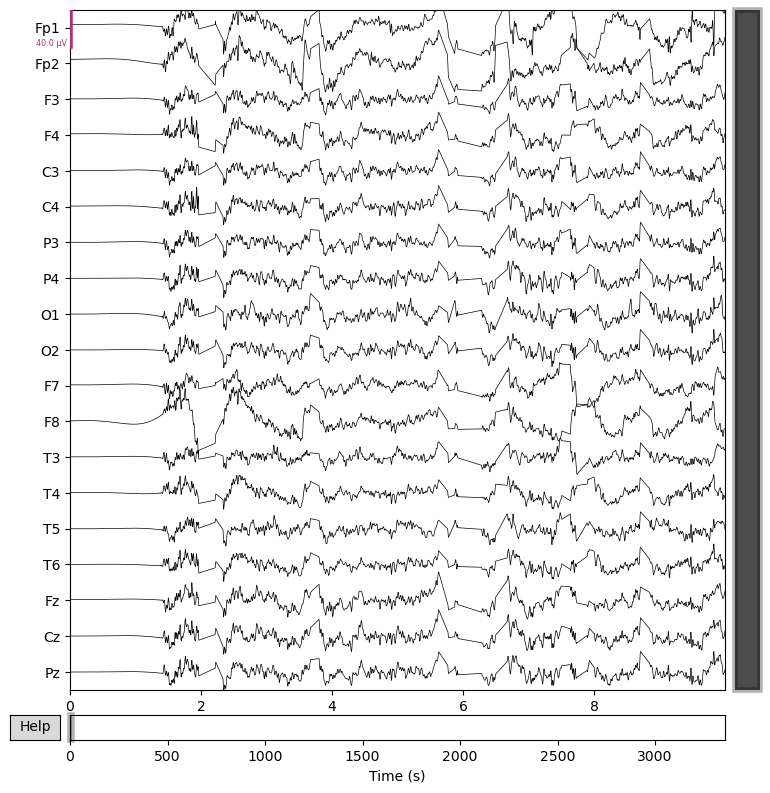

In [102]:
metadata, data = u.read_file(files[0])
print(data.shape)
raw=u.read_file_to_raw(files[0])
p.preprocess_eeg(raw)
raw.compute_psd().plot()
_=raw.plot()


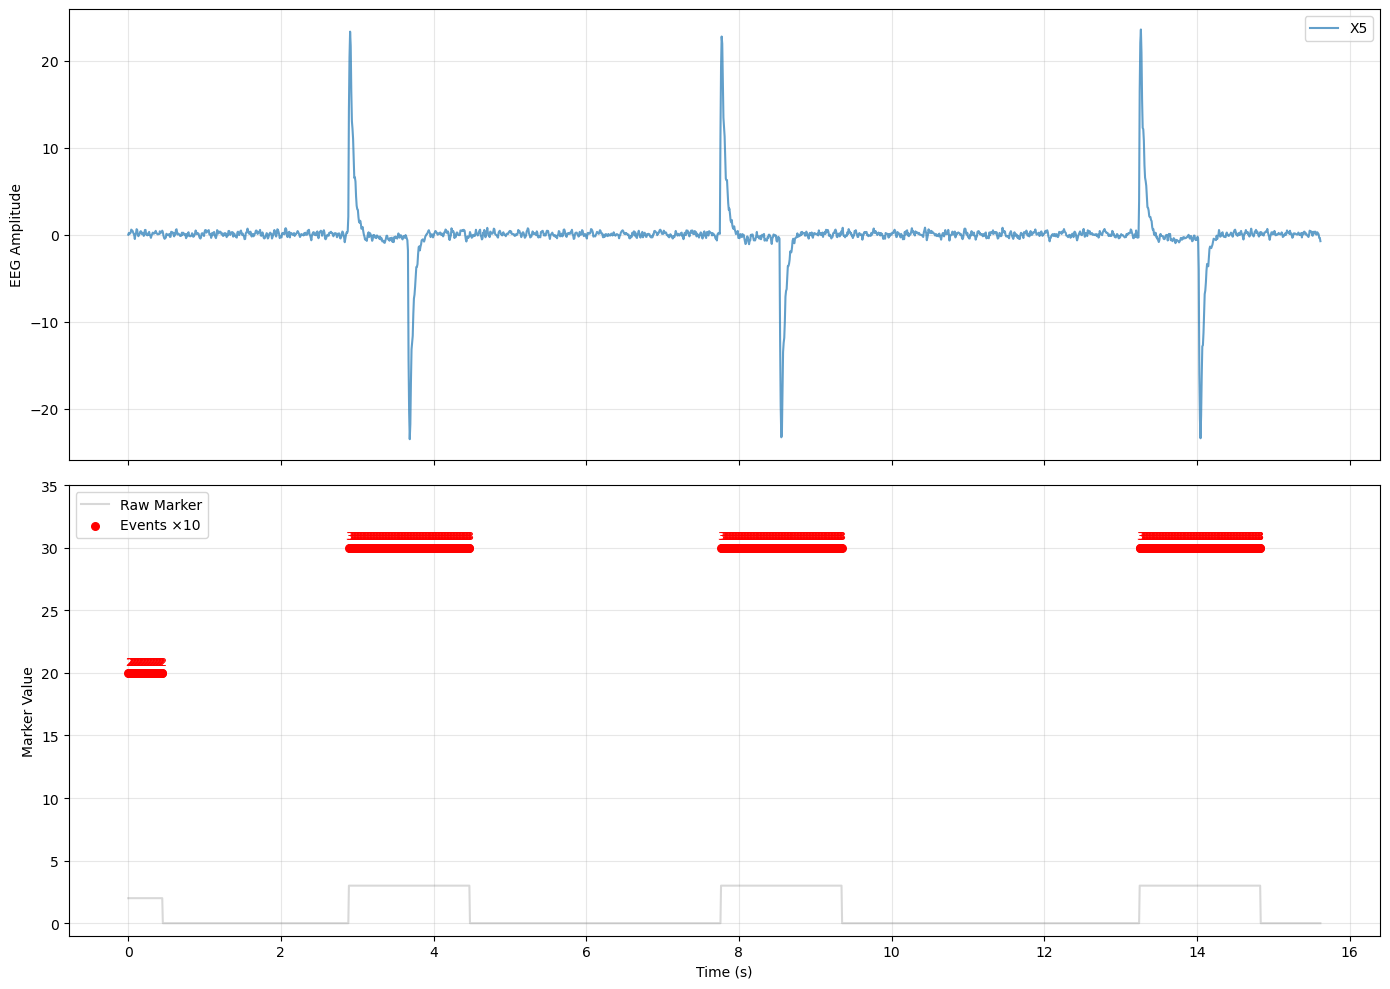

Events in this window: {2: 58, 3: 609}
{0: 476168, 1: 61490, 2: 69202, 3: 64740}


In [103]:
u.plot_eeg_signals_with_events(data, first_sample=50000, window_size=2000, freq=128, channels=[ "X5" ,"marker"])
# Count all unique values
unique_values, counts = np.unique(data["marker"], return_counts=True)
print(dict(zip(unique_values, counts)))


In [104]:
events = u.find_events_from_marker(data["marker"])
epochs = mne.Epochs(
        raw=raw,  # You might need to create a Raw object first
        events=events,
        tmin= -0.5,  # Start before event
        tmax= +1,      # End after event
        baseline=(None, 0),       # Baseline correction
        preload=True
    )
df = u.epochs_to_polars(epochs)


Not setting metadata
1920 matching events found
Setting baseline interval to [-0.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1920 events and 301 original time points ...
0 bad epochs dropped


In [111]:
u.quick_XGBOOST_test(df)

(1920, 5719) (1920,)
Starting XGBoost training...
Training complete.

Model Accuracy on Test Set: 74.22%


In [113]:
C = len(df.columns)-3 # number of channels
T = df.group_by("epoch_id").agg(
    pl.count().alias("rows_per_epoch")
).select(
    pl.col("rows_per_epoch")
).head(1).item()

N = len(df["label"].unique()) # number of classes
print(f"C: {C}, T: {T}, N: {N}")



C:\Users\josub\AppData\Local\Temp\ipykernel_37876\2107012675.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("rows_per_epoch")


C: 19, T: 301, N: 4


In [114]:
channel_cols = df.columns[3:] 
C = len(channel_cols)  # number of channels
N = len(df['label'].unique())  # number of classes

rows_per_epoch = df.group_by("epoch_id").agg(pl.len().alias("rows_per_epoch"))
T = rows_per_epoch['rows_per_epoch'][0]  # first epoch row count

print(f"C: {C}, T: {T}, N: {N}")

# Convert to numpy array
X_np = df.select(channel_cols).to_numpy()  #(n_rows, C_channels)
# Number of epochs
n_epochs = df['epoch_id'].max() + 1  # assuming epoch_id starts from 0
# Reshape:
X_np = X_np.reshape(n_epochs,  C, T)
X_np = X_np[:, :, :, np.newaxis]      

# Labels
unique_labels = df["label"].unique().to_list()
unique_labels = sorted(unique_labels)
print("Original labels:", unique_labels)

# Map them to 0..N-1
label_map = {old: new for new, old in enumerate(unique_labels)}
print("Label map:", label_map)

# Apply mapping
y_np = df.group_by("epoch_id").first().select("label").to_numpy().flatten()
print("y_np before mapping:", y_np)
y_np = np.array([label_map[int(l)] for l in y_np])
y_np = to_categorical(y_np, num_classes=N)

print(f"X_np shape: {X_np.shape}, y_np shape: {y_np.shape}")

C: 19, T: 301, N: 4
Original labels: [0, 1, 2, 3]
Label map: {0: 0, 1: 1, 2: 2, 3: 3}
y_np before mapping: [3 0 0 ... 2 0 0]
X_np shape: (1920, 19, 301, 1), y_np shape: (1920, 4)


In [115]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X_np, y_np, test_size=0.3, random_state=42, stratify=y_np)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(X_train.shape, X_val.shape, X_test.shape)


(1344, 19, 301, 1) (288, 19, 301, 1) (288, 19, 301, 1)


In [116]:
model = m.EEGNet(nb_classes=N,Chans = C, Samples =T )
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


C:\Users\josub\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 19, 301, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 19, 301, 8)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 19, 301, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_6              │ (None, 1, 301, 16)     │           304 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 1, 301, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 1, 301, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_10            │ (None, 1, 75, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1, 75, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_5              │ (None, 1, 75, 16)      │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 1, 75, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 1, 75, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_11            │ (None, 1, 9, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1, 9, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,068 (8.08 KB)

 Trainable params: 1,988 (7.77 KB)

 Non-trainable params: 80 (320.00 B)

In [117]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_model.h5", monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4405 - loss: 1.3723

42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.4829 - loss: 1.3497 - val_accuracy: 0.5000 - val_loss: 1.3462
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5039 - loss: 1.2708

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.5000 - loss: 1.2573 - val_accuracy: 0.5000 - val_loss: 1.3154
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5039 - loss: 1.2479

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.5000 - loss: 1.2542 - val_accuracy: 0.5000 - val_loss: 1.3124
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5039 - loss: 1.2390

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.5000 - loss: 1.2467 - val_accuracy: 0.5000 - val_loss: 1.3116
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5039 - loss: 1.2403

...

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.5000 - loss: 1.2493 - val_accuracy: 0.5000 - val_loss: 1.2904
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5039 - loss: 1.2452

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.5000 - loss: 1.2438 - val_accuracy: 0.5000 - val_loss: 1.2786
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.5000 - loss: 1.2499 - val_accuracy: 0.5000 - val_loss: 1.2855
Epoch 9/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5039 - loss: 1.2400

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.5000 - loss: 1.2447 - val_accuracy: 0.5000 - val_loss: 1.2755
Epoch 10/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5039 - loss: 1.2370

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.5000 - loss: 1.2468 - val_accuracy: 0.5000 - val_loss: 1.2707
Epoch 11/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.5000 - loss: 1.2483 - val_accuracy: 0.5000 - val_loss: 1.3044
Epoch 12/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.5000 - loss: 1.2462 - val_accuracy: 0.5000 - val_loss: 1.2842
Epoch 13/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.5000 - loss: 1.2394 - val_accuracy: 0.5000 - val_loss: 1.3614
Epoch 14/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.5000 - loss: 1.2400 - val_accuracy: 0.1597 - val_loss: 1.4396
Epoch 15/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.5007 - loss: 1.2413 - val_accuracy: 0.3264 - val_loss: 1.3671
Epoch 16/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5037 - loss: 1.2386

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.4993 - loss: 1.2426 - val_accuracy: 0.5000 - val_loss: 1.2543
Epoch 17/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.5000 - loss: 1.2386 - val_accuracy: 0.5000 - val_loss: 1.2831
Epoch 18/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.4993 - loss: 1.2425 - val_accuracy: 0.5000 - val_loss: 1.3646
Epoch 19/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.4993 - loss: 1.2403 - val_accuracy: 0.5000 - val_loss: 1.2622
Epoch 20/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.4993 - loss: 1.2340 - val_accuracy: 0.5000 - val_loss: 1.3518
Epoch 21/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.4993 - loss: 1.2354 - val_accuracy: 0.5000 - val_loss: 1.2793
Epoch 22/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.4993 - loss: 1.2272 - val_accuracy: 0.5000 - val_loss: 1.3446
Epoch 23/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.5007 - loss: 1.2310 - val_accuracy: 0.5000 

In [118]:
loss, acc = model.evaluate(X_test, y_test)
print("Test accuracy:", acc)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5000 - loss: 1.2523
Test accuracy: 0.5
